Feature Selection and Correlation for Prediction Models used in MPC

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import os
plt.style.use('seaborn-darkgrid')

Power Model - (a) Find the datatypes of the variables in the dataset. Are there any missing values?

In [3]:
df = pd.read_csv('prepared_data_1hr.csv', index_col=0, header=0)
print(df.size)
print(df.shape)
print(df.head(5))
print("The datatypes of the variables in the dataset:\n")
df.info()

79920
(740, 108)
         time formatted_time  tesBed.TOut.y  tesBed.weaBus.TWetBul  \
4  18331200.0    08-01 04:00       17.79250               16.39324   
5  18334800.0    08-01 05:00       18.26434               17.17437   
6  18338400.0    08-01 06:00       19.93170               18.48196   
7  18342000.0    08-01 07:00       22.14208               18.82546   
8  18345600.0    08-01 08:00       23.84335               19.08276   

   tesBed.weaBus.relHum  tesBed.weaBus.HGloHor  tesBed.uMod  \
4              0.870237               5.012894          1.0   
5              0.899621              99.668884          0.0   
6              0.872911             241.892790         -1.0   
7              0.733650             325.366820         -1.0   
8              0.641871             526.739600         -1.0   

   tesBed.uModActual.y  tesBed.occSch.occupied  tesBed.modCon.y  ...  \
4                  1.0                     0.0              3.0  ...   
5                  0.0                 

## Check variables

No handles with labels found to put in legend.


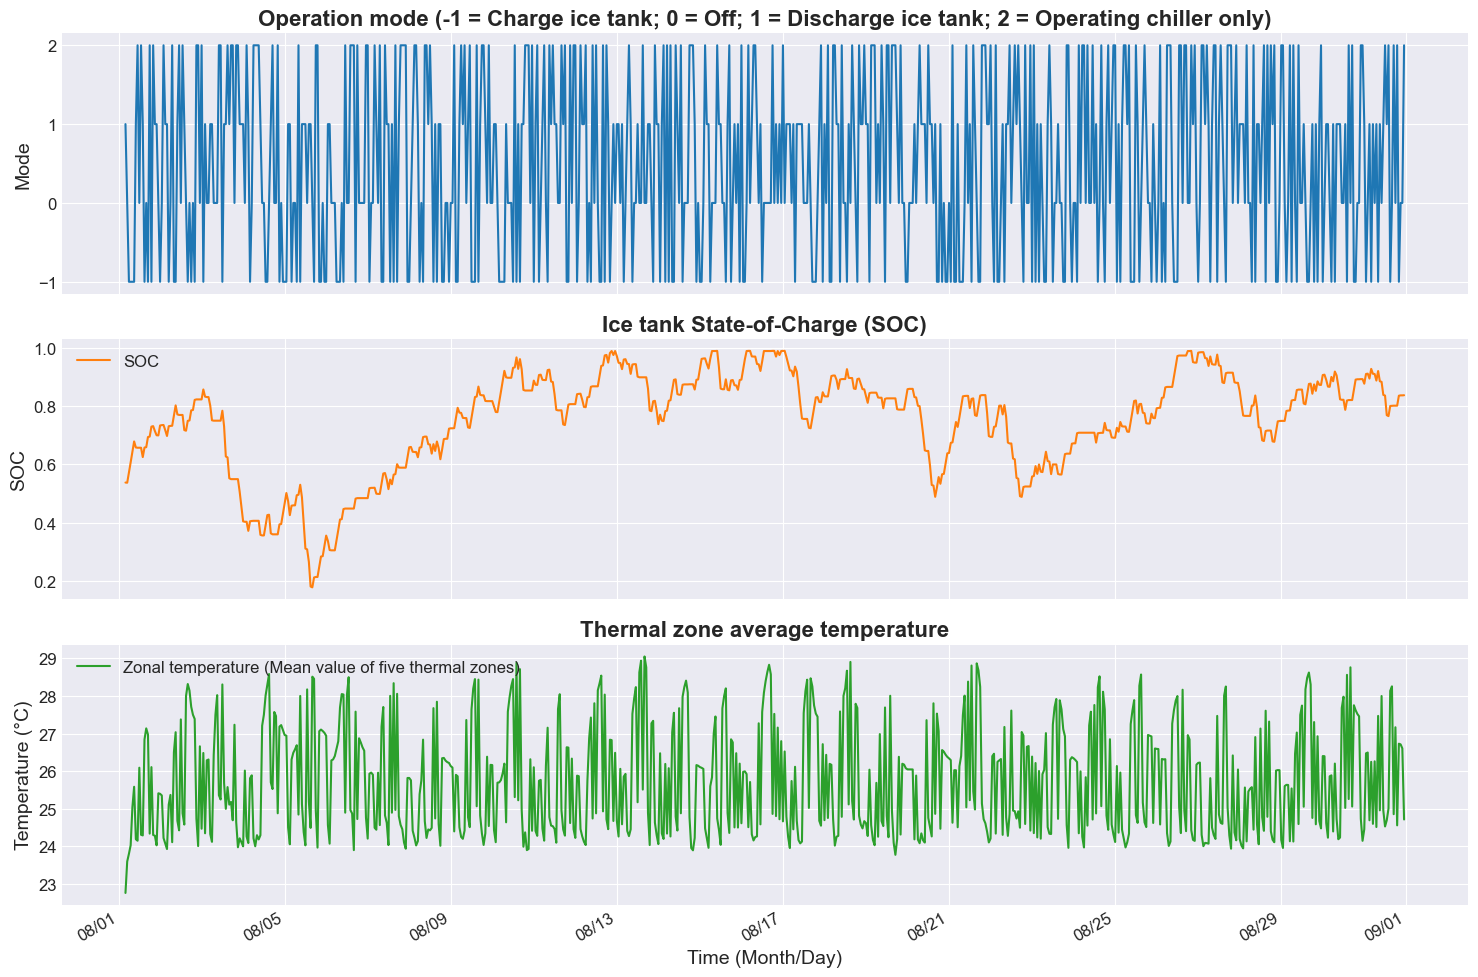

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('prepared_data_1hr.csv', index_col=1, header=0)

# Convert time index from seconds to datetime (assuming epoch)
df.index = pd.to_datetime(df.index, unit='s')

# Set Global Font Size
plt.rcParams.update({
    'font.size': 14,              # General font size
    'axes.titlesize': 16,         # Axes title
    'axes.labelsize': 14,         # Axes labels
    'xtick.labelsize': 12,        # X tick labels
    'ytick.labelsize': 12,        # Y tick labels
    'legend.fontsize': 12,        # Legend
    'figure.titlesize': 18        # Figure title
})

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Subplot (1,1): Operation Mode
axes[0].plot(df.index, df['tesBed.uModActual.y'], ) # label='Actual operation mode'
axes[0].set_title('Operation mode (-1 = Charge ice tank; 0 = Off; 1 = Discharge ice tank; 2 = Operating chiller only)', fontweight='bold')
axes[0].set_ylabel('Mode')
axes[0].set_yticks([-1, 0, 1, 2])
axes[0].legend()
axes[0].grid(True)

# Subplot (2,1): Ice Tank SOC
axes[1].plot(df.index, df['tesBed.iceTan.SOC'], label='SOC', color='tab:orange')
axes[1].set_title('Ice tank State-of-Charge (SOC)', fontweight='bold')
axes[1].set_ylabel('SOC')
axes[1].legend(loc='upper left')
axes[1].grid(True)

# Subplot (3,1): Mean Zonal Temperature
zone_vars = [
    'tesBed.conVAVCor.TZon',
    'tesBed.conVAVSou.TZon',
    'tesBed.conVAVEas.TZon',
    'tesBed.conVAVNor.TZon',
    'tesBed.conVAVWes.TZon'
]
df['Zonal_Temp_Mean'] = df[zone_vars].mean(axis=1)
axes[2].plot(df.index, df['Zonal_Temp_Mean'], label='Zonal temperature (Mean value of five thermal zones)', color='tab:green')
axes[2].set_title('Thermal zone average temperature', fontweight='bold')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Time (Month/Day)')
axes[2].legend(loc='upper left')
axes[2].grid(True)

# Format the x-axis
axes[2].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("results_dnn/operation_SOC_temperature_plot.png", dpi=300, bbox_inches='tight')
#plt.show()


Power Model - (b) Compute the summary statistics for each of the variables

In [5]:
df_power = df[['tesBed.uModActual.y',
            #'bChi.y', 
            #'bIce.y',
            #'tesBed.occSch.occupied',
            #'tesBed.iceTan.SOC_his1',
            #'tesBed.ave.y_his1', 
            #'tesBed.TOut.y_his1',
            'tesBed.TOut.y',
            #'tesBed.weaBus.HGloHor_his1','tesBed.weaBus.HGloHor',
            #'Ptot_his1', 
            'Ptot'
            ]]
df_power.describe()

,tesBed.uModActual.y,tesBed.TOut.y,Ptot
count,740.000000,740.000000,740.000000
mean,0.504054,21.787179,7269.088649
std,1.116361,4.224588,6628.062993
min,-1.000000,11.685800,-0.000000
25%,0.000000,18.917493,-0.000000
50%,0.000000,21.700000,8317.680000
75%,2.000000,24.941320,8888.375000
max,2.000000,31.700000,32208.300000


Power Model - (c) Describe the shape of the distribution of each variable using a suitable graphical method. Justify your choice.

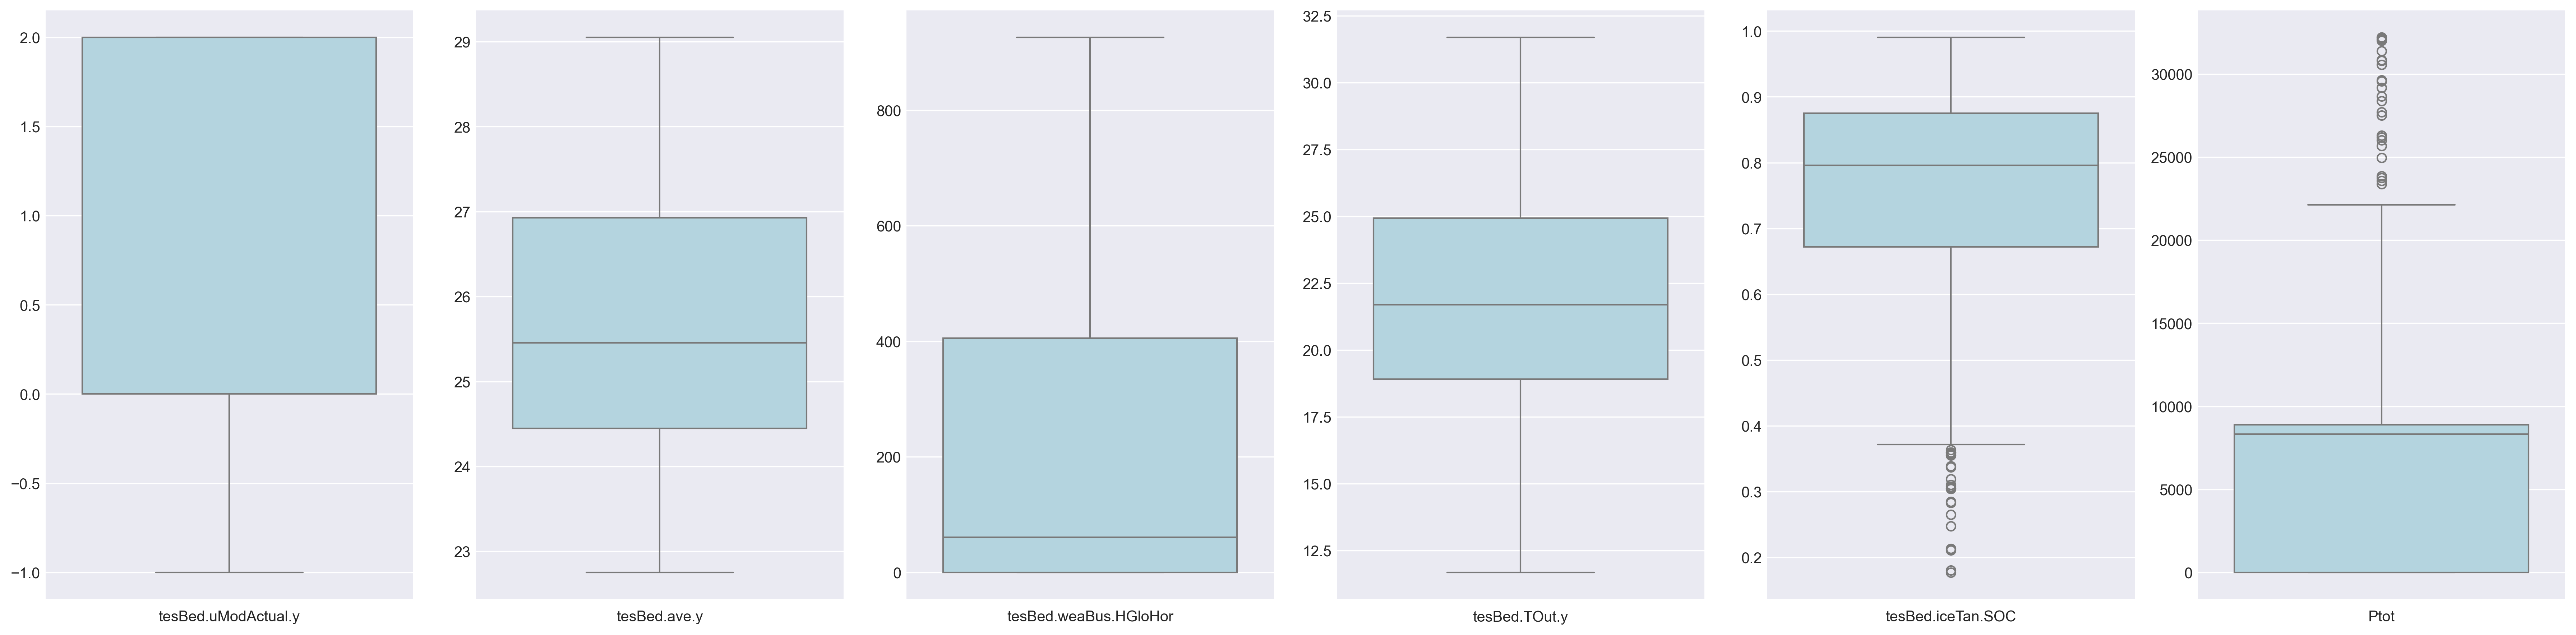

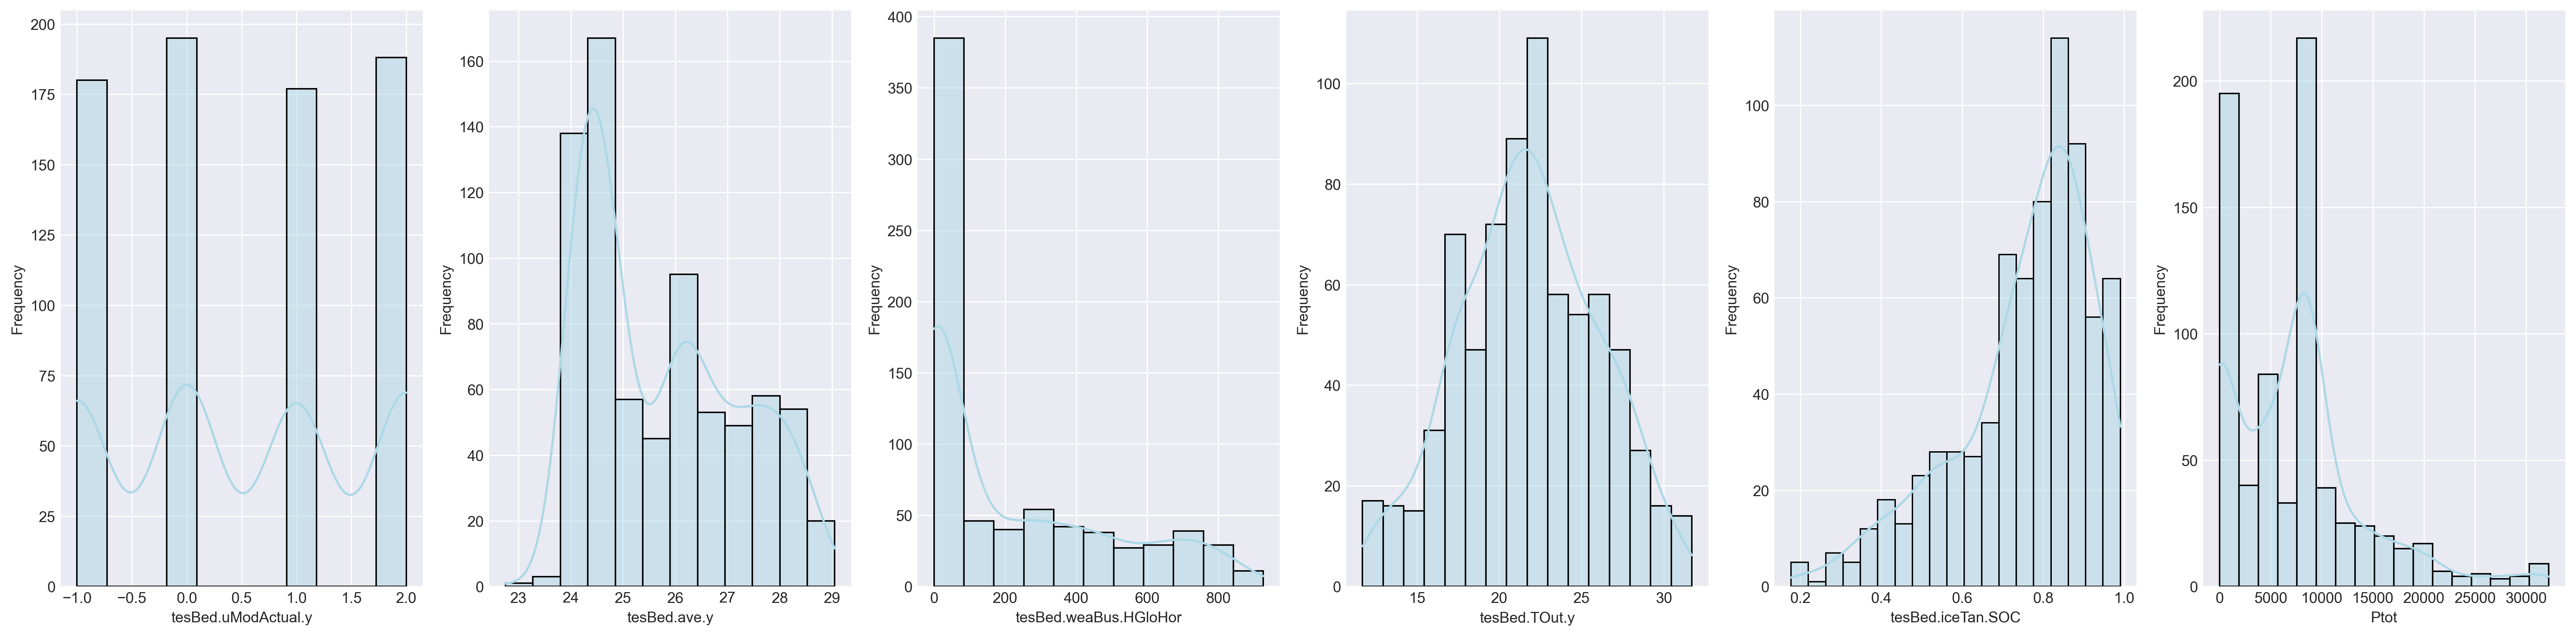

In [19]:
df_all = df[['tesBed.uModActual.y',
            'tesBed.ave.y', 
            'tesBed.weaBus.HGloHor',
            'tesBed.TOut.y',
            #'tesBed.occSch.occupied',
            'tesBed.iceTan.SOC',
            'Ptot'
            ]]
data_df = df_all
targets = [t for t in data_df.columns]

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.boxplot(data=data_df, y=value, color="lightblue", ax=axs[count]) #
    axs[count].set_xlabel(value)
    axs[count].set_ylabel('')
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.histplot(data=data_df, x=value, color="lightblue", kde=True, ax=axs[count])
    axs[count].set_xlabel(value)
    axs[count].set_ylabel('Frequency')
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

Power Model - (d) Check for the normality of each numeric variables.

Normality check: QQ plot showing the scatter plot of points in a diagonal line,     closely fitting the expected diagonal pattern for a sample from a Gaussian distribution.        If R2 is closer to 1, then the normality is closer to the ideal Gaussian distribution.


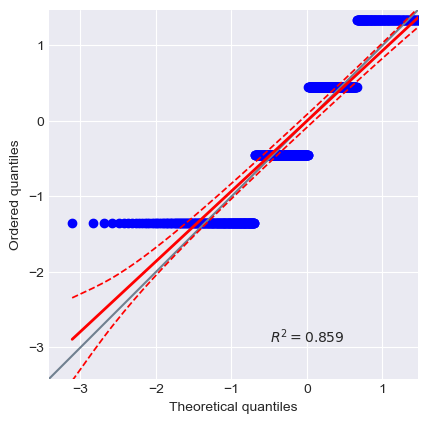

In [5]:
import pingouin as pg
pg.qqplot(df_power['tesBed.uModActual.y'], dist='norm')
print("Normality check: QQ plot showing the scatter plot of points in a diagonal line, \
    closely fitting the expected diagonal pattern for a sample from a Gaussian distribution.\
        If R2 is closer to 1, then the normality is closer to the ideal Gaussian distribution.")

Power Model - (e) What is the target varible of this dataset ?

In [6]:
print("Target Variable:",df_power.columns[-1])

Target Variable: Ptot


Power Model - (f) By using a suitable graphical representation, visualize associations between the target variable and other variables.

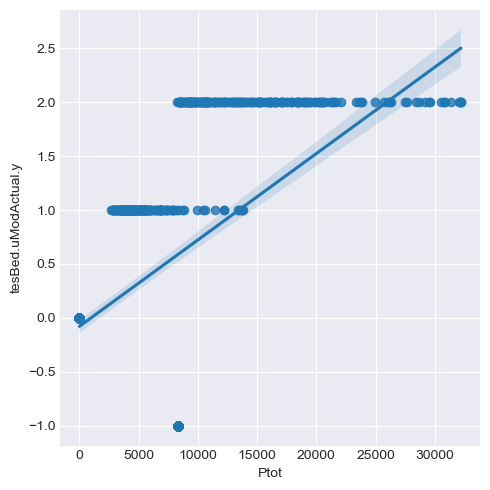

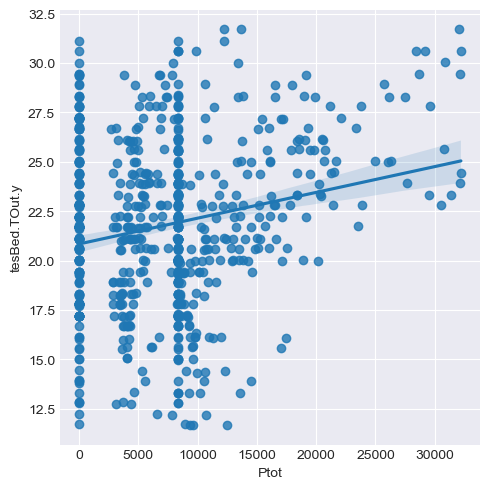

In [7]:
features = [t for t in df_power.columns[:-1]]
for count, value in enumerate(features):
    sns.lmplot(data=df_power, x="Ptot", y=value)

Power Model - (g) Compute the correlation between variables. Create heat maps to visualize the correlation matrixes.

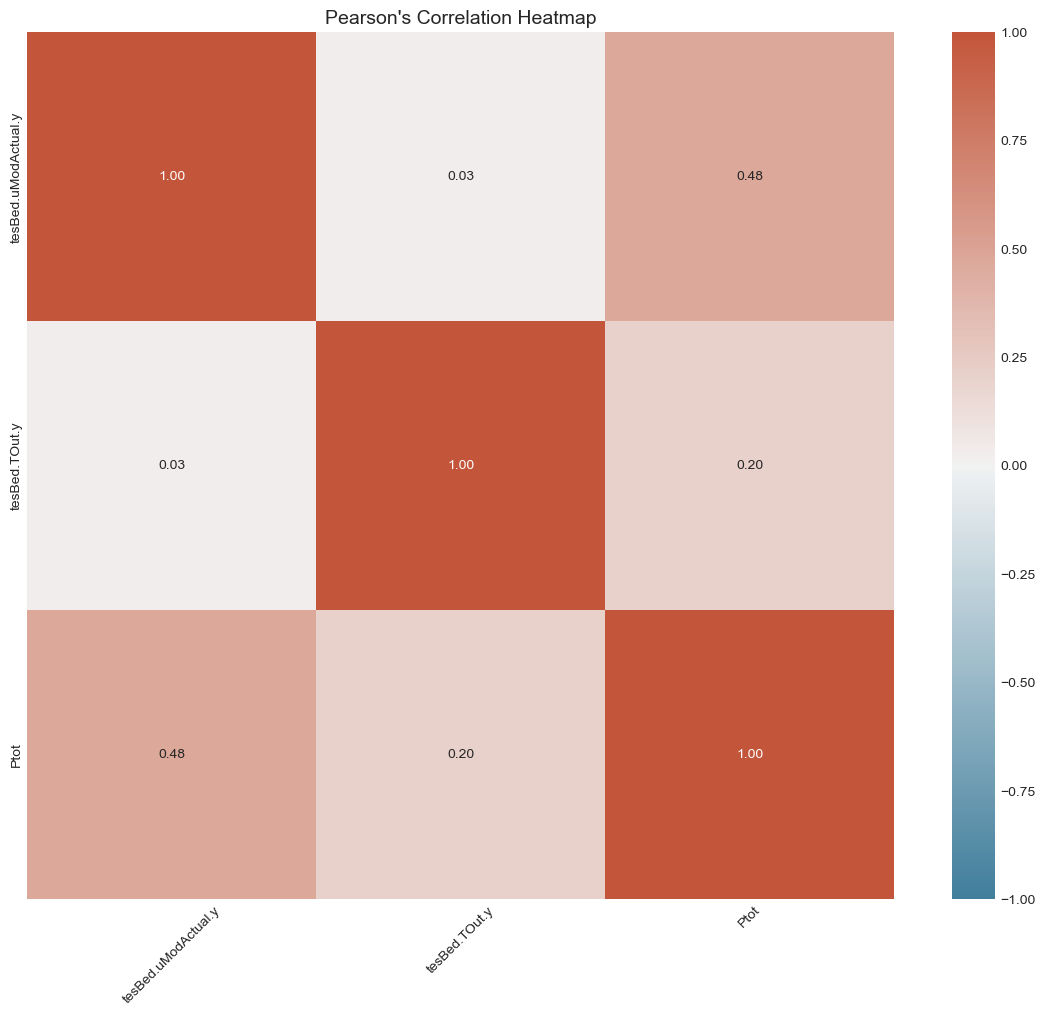

In [8]:
plt.figure(figsize=(12, 10))
corr = df_power.corr(method='pearson')
#print("Pearson's correlation:\n",corr)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, square=True, vmin=-1, vmax=1, cmap=cmap, annot=True, fmt=".2f")
plt.title("Pearson's Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout() 
# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_pearson_power.png', dpi=300)

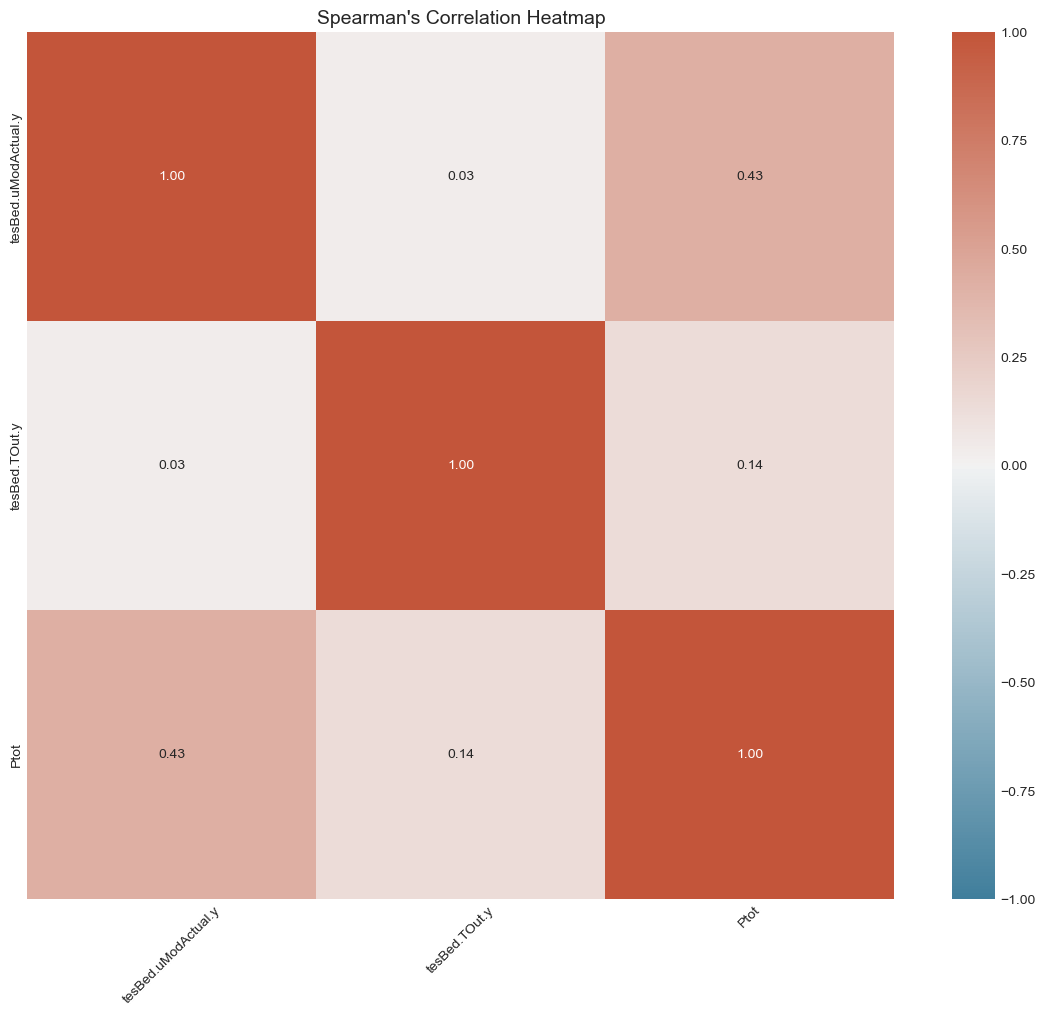

In [9]:
plt.figure(figsize=(12, 10))
corr2 = df_power.corr(method='spearman')
#print("Spearman's correlation:\n",corr2)
cmap2 = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr2, square=True, vmin=-1, vmax=1, cmap=cmap2, annot=True, fmt=".2f")
plt.title("Spearman's Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout() 
# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_spearman_power.png', dpi=300)

interval columns not set, guessing: ['tesBed.uModActual.y', 'tesBed.TOut.y', 'Ptot']
Phik correlation:
                      tesBed.uModActual.y  tesBed.TOut.y      Ptot
tesBed.uModActual.y             1.000000       0.000000  0.938367
tesBed.TOut.y                   0.000000       1.000000  0.374874
Ptot                            0.938367       0.374874  1.000000


<AxesSubplot:>

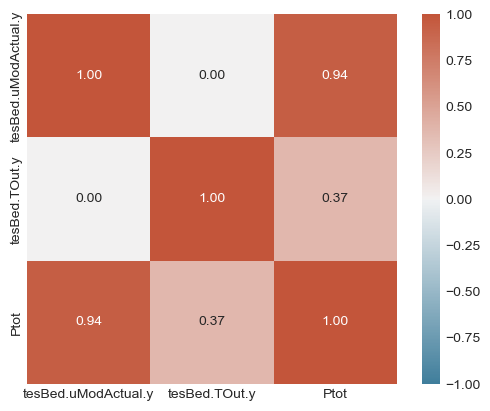

In [10]:
import phik
corr3 = df_power.phik_matrix()
print("Phik correlation:\n",corr3)
cmap3 = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr3, square=True, vmin=-1, vmax=1, cmap=cmap3, annot=True, fmt=".2f")

State-of-Charge Model - Compute the correlation between variables. Create heat maps to visualize the correlation matrixes.

In [11]:
df_SOC = df[['tesBed.uModActual.y', # -1: Charge TES; 0: off; 1: Discharge TES; 2: Discharge chiller
            #'bChi.y', # Chiller on/off
            #'bIce.y', # TES on/off
            #'tesBed.occSch.occupied', # Ocuupied status
            'tesBed.iceTan.SOC_his1', # historical SOC
            #'tesBed.ave.y_his1', # Average Zonal temperature
            'tesBed.iceTan.SOC',
            #'tesBed.weaBus.HGloHor',
            #'tesBed.TOut.y',
            ]] 
df_SOC.describe()

,tesBed.uModActual.y,tesBed.iceTan.SOC_his1,tesBed.iceTan.SOC
count,740.000000,740.000000,740.000000
mean,0.504054,0.753804,0.754191
std,1.116361,0.169915,0.169781
min,-1.000000,0.177074,0.177074
25%,0.000000,0.671859,0.672036
50%,0.000000,0.795289,0.795866
75%,2.000000,0.875337,0.875337
max,2.000000,0.990514,0.990514


State-of-Charge Model - Distribution of each feature

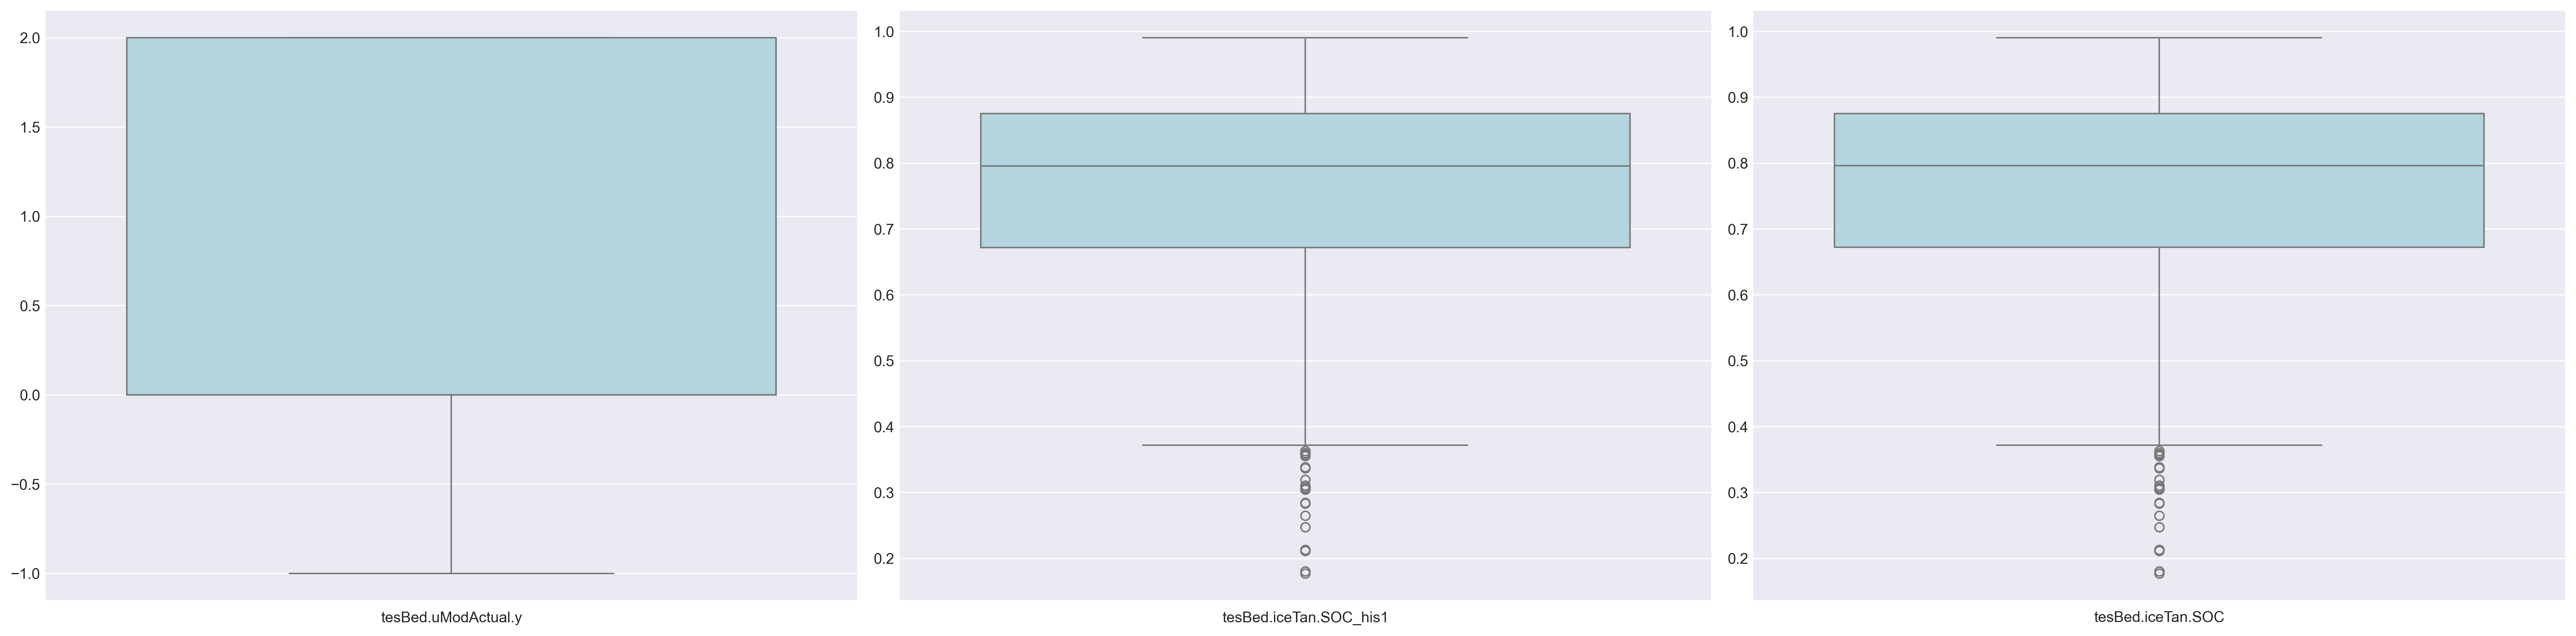

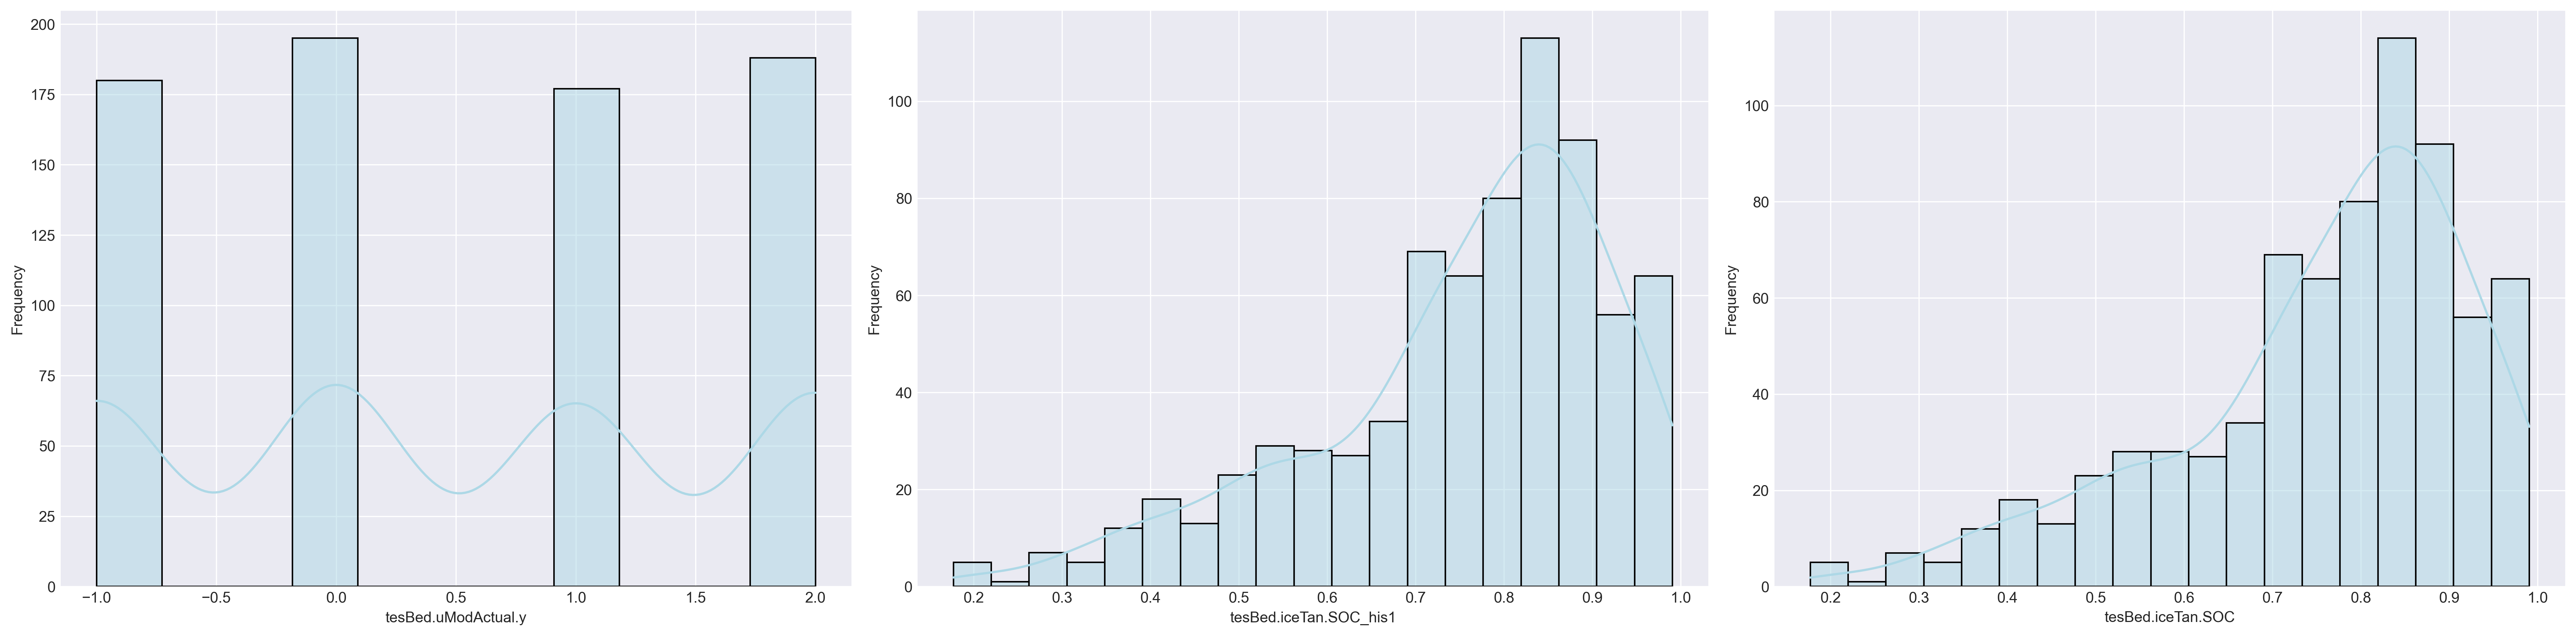

In [12]:
data_df = df_SOC
targets = [t for t in data_df.columns]

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.boxplot(data=data_df, y=value, color="lightblue", ax=axs[count]) #
    axs[count].set_xlabel(value)
    axs[count].set_ylabel('')
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.histplot(data=data_df, x=value, color="lightblue", kde=True, ax=axs[count])
    axs[count].set_xlabel(value)
    axs[count].set_ylabel('Frequency')
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

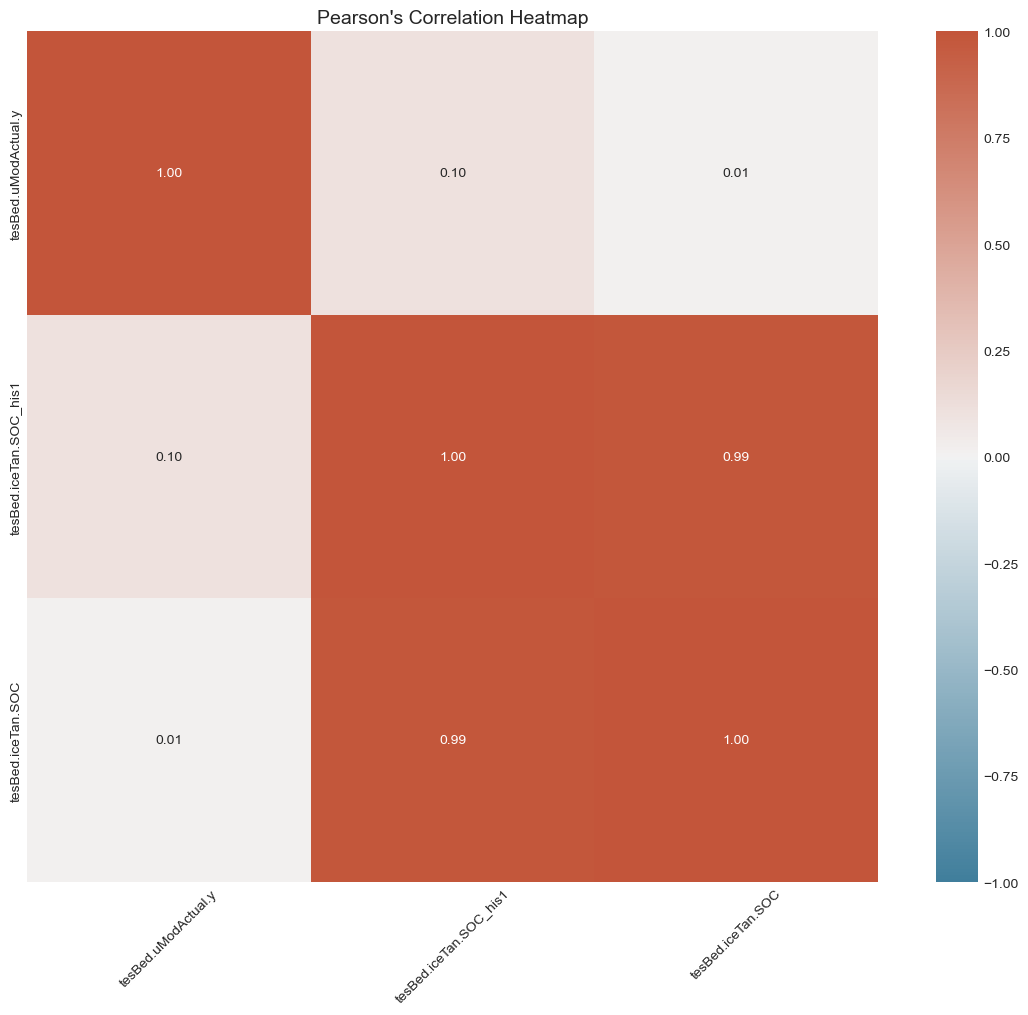

In [13]:
plt.figure(figsize=(12, 10))
corr_SOC = df_SOC.corr(method='pearson')
#print("Pearson's correlation:\n",corr_SOC)
cmap_SOC = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_SOC, square=True, vmin=-1, vmax=1, cmap=cmap_SOC, annot=True, fmt=".2f")
# Add a title
plt.title("Pearson's Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout() 
# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_pearson_SOC.png', dpi=300)

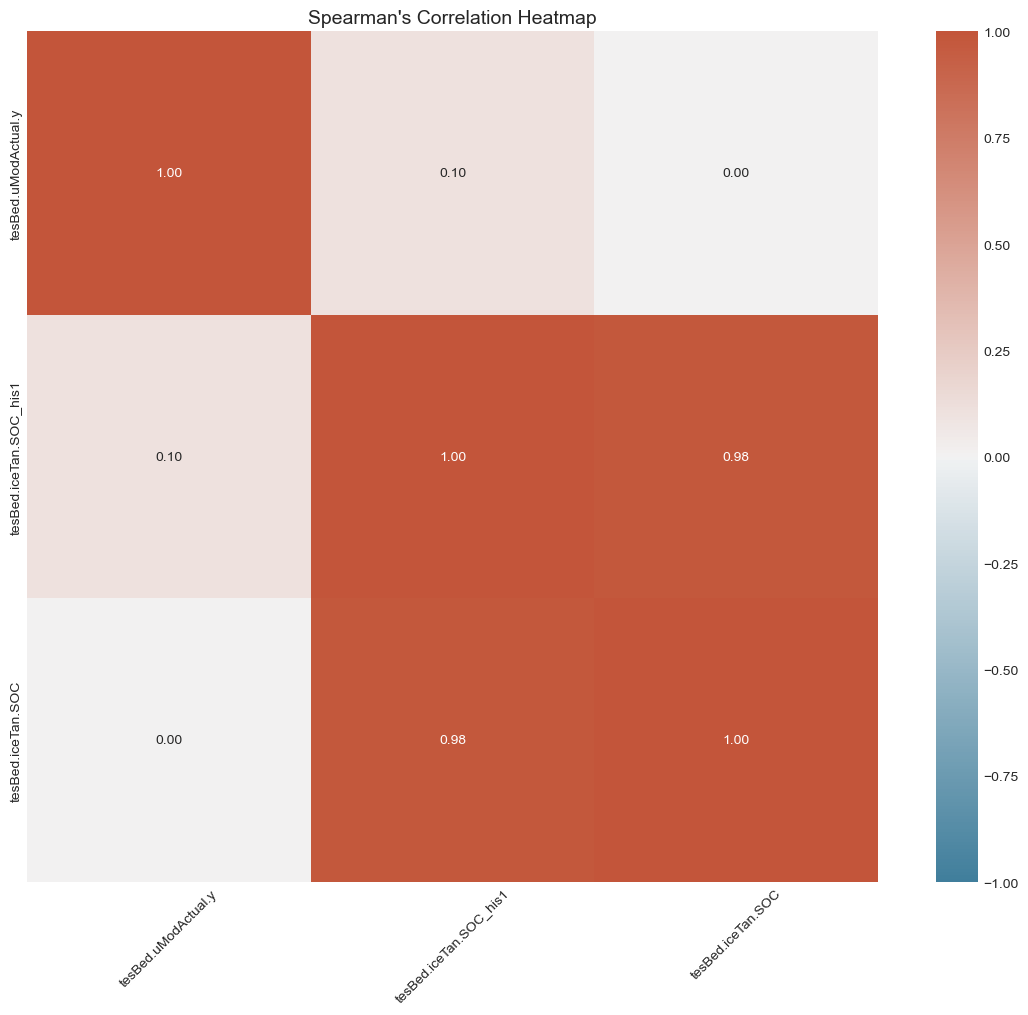

In [14]:
plt.figure(figsize=(12, 10))
corr_spear_SOC = df_SOC.corr(method='spearman')
#print("Spearman's correlation:\n",corr_spear_SOC)
cmap_spear_SOC = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_spear_SOC, square=True, vmin=-1, vmax=1, cmap=cmap_spear_SOC, annot=True, fmt=".2f")
# Add a title
plt.title("Spearman's Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout() 
# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_spearman_SOC.png', dpi=300)

#### Test more features

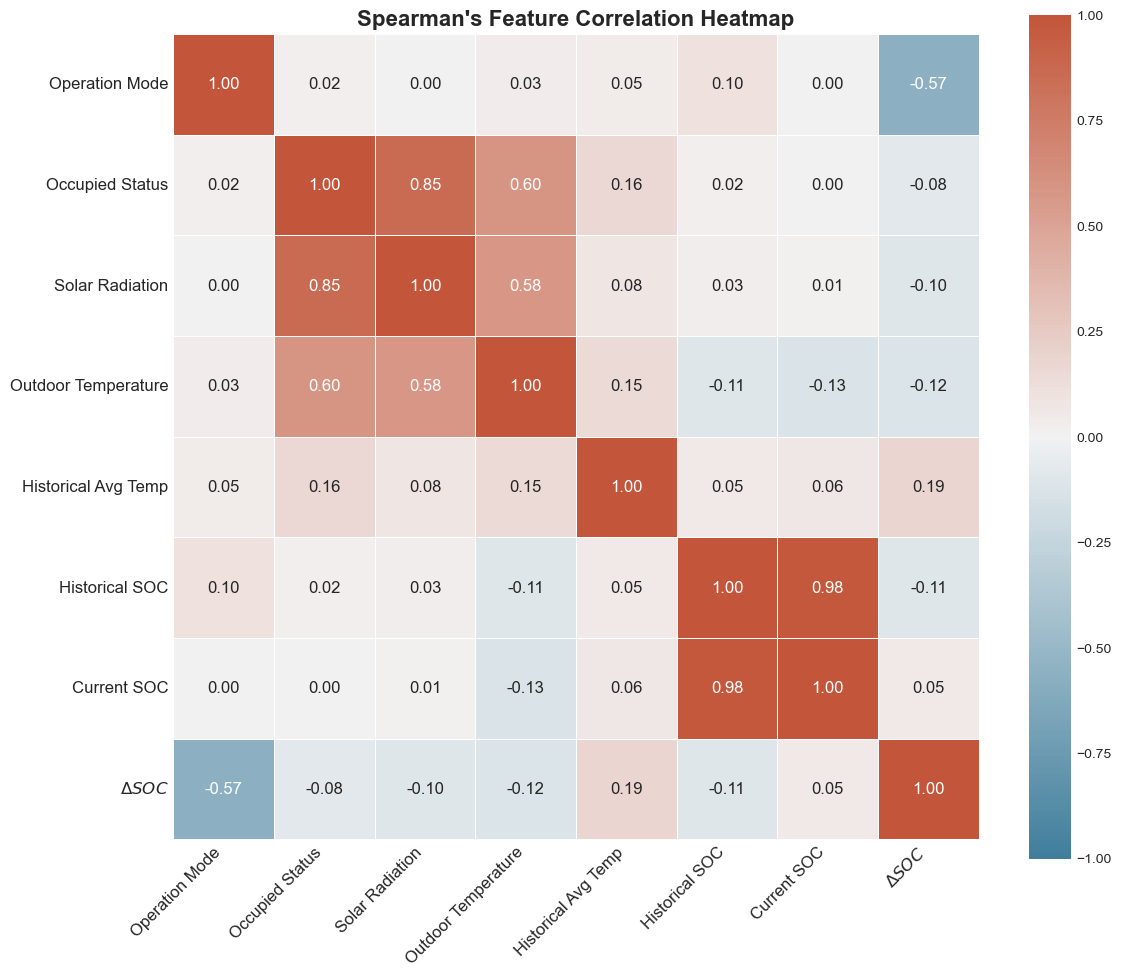

In [3]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Select relevant features
df_SOC = df[['tesBed.uModActual.y',         # -1: Charge TES; 0: off; 1: Discharge TES; 2: Discharge chiller
             'tesBed.occSch.occupied',      # Occupied status
             'tesBed.weaBus.HGloHor',       # Global horizontal solar radiation
             'tesBed.TOut.y',               # Outdoor air temperature
             'tesBed.ave.y_his1',           # Historical average zone temperature
             'tesBed.iceTan.SOC_his1',      # Historical SOC
             'tesBed.iceTan.SOC',           # Target SOC
             'delta_SOC'                    # Change in SOC
            ]]

# Rename columns to plain language
df_SOC = df_SOC.rename(columns={
    'tesBed.uModActual.y': 'Operation Mode',
    'tesBed.occSch.occupied': 'Occupied Status',
    'tesBed.weaBus.HGloHor': 'Solar Radiation',
    'tesBed.TOut.y': 'Outdoor Temperature',
    'tesBed.ave.y_his1': 'Historical Avg Temp',
    'tesBed.iceTan.SOC_his1': 'Historical SOC',
    'tesBed.iceTan.SOC': 'Current SOC',
    'delta_SOC': '$\Delta SOC$'
})

# Calculate Spearman correlation
corr_spear_SOC = df_SOC.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12, 10))
cmap_spear_SOC = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_spear_SOC, square=True, vmin=-1, vmax=1, cmap=cmap_spear_SOC,
            annot=True, fmt=".2f", annot_kws={"size": 12}, linewidths=0.5)

# Customize appearance
plt.title("Spearman's Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig('results_dnn/correlation_spearman_moreFeatures_SOC.png', dpi=300)
plt.show()


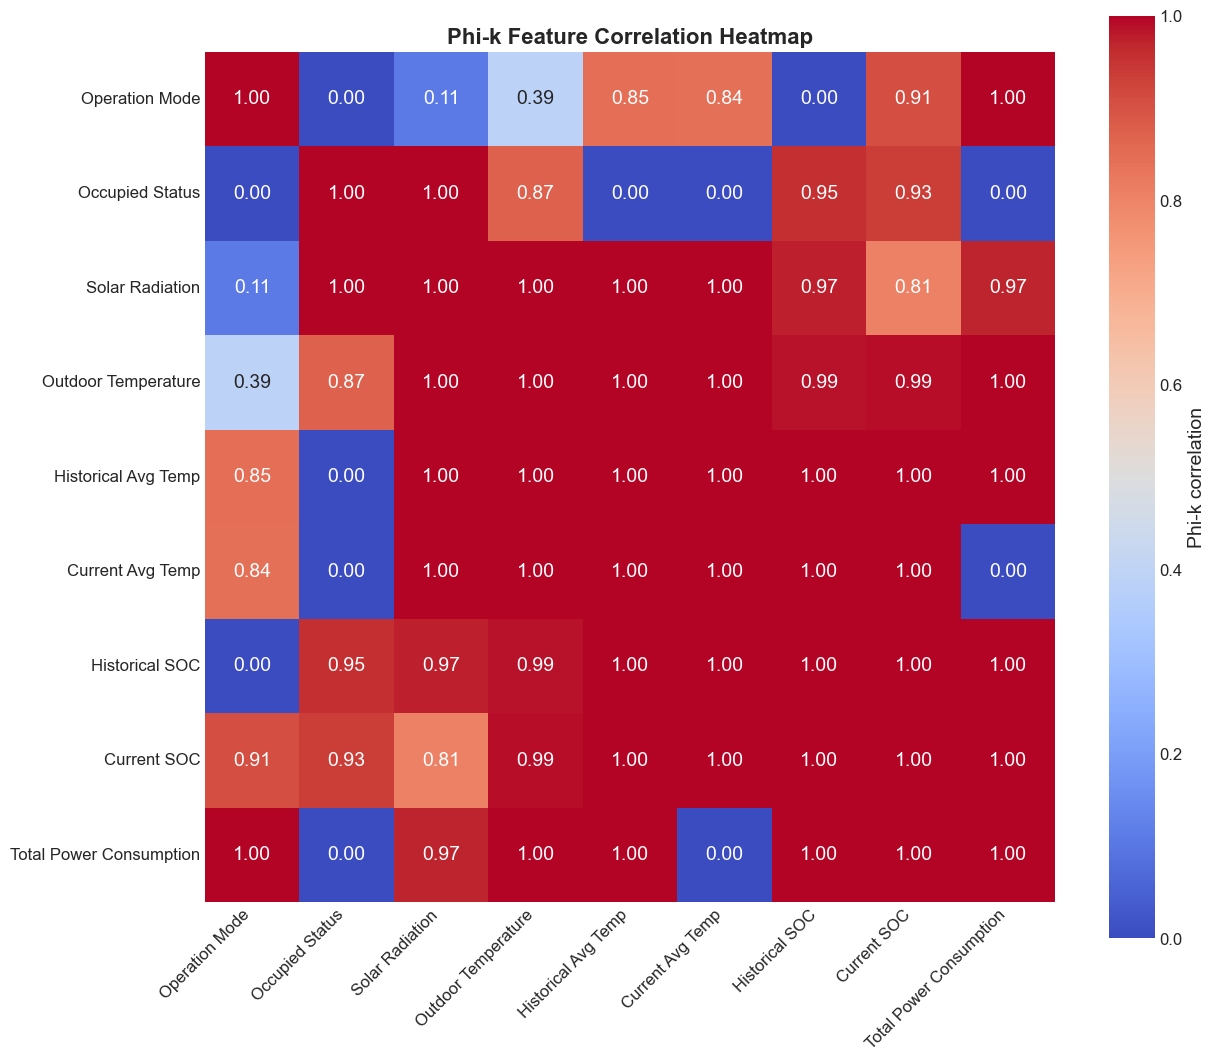

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: (Optional) Install phik if not already installed
# pip install phik

from phik import phik_matrix

# Step 2: Select relevant features from your dataframe
df_SOC = df[['tesBed.uModActual.y',        # Operation Mode
             'tesBed.occSch.occupied',     # Occupied Status
             'tesBed.weaBus.HGloHor',      # Solar Radiation
             'tesBed.TOut.y',              # Outdoor Temperature
             'tesBed.ave.y_his1',          # Historical Avg Temp
             'tesBed.ave.y',               # Current Avg Temp ← NEW
             'tesBed.iceTan.SOC_his1',     # Historical SOC
             'tesBed.iceTan.SOC',          # Current SOC
             'Ptot'                        # Total Power Consumption ← NEW
            ]]

# Step 3: Rename columns to plain language
df_SOC = df_SOC.rename(columns={
    'tesBed.uModActual.y': 'Operation Mode',
    'tesBed.occSch.occupied': 'Occupied Status',
    'tesBed.weaBus.HGloHor': 'Solar Radiation',
    'tesBed.TOut.y': 'Outdoor Temperature',
    'tesBed.ave.y_his1': 'Historical Avg Temp',
    'tesBed.ave.y': 'Current Avg Temp',                 # NEW label
    'tesBed.iceTan.SOC_his1': 'Historical SOC',
    'tesBed.iceTan.SOC': 'Current SOC',
    'Ptot': 'Total Power Consumption'                   # NEW label
})

# Step 4: Compute Phi-k correlation matrix
phik_corr = df_SOC.phik_matrix(interval_cols=[])

# Step 5: Plot the heatmap
plt.figure(figsize=(13, 11))
sns.heatmap(phik_corr, vmin=0, vmax=1, cmap='coolwarm', annot=True, fmt=".2f", square=True,
            cbar_kws={'label': 'Phi-k correlation'})
plt.title("Phi-k Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Step 6: Save the figure
plt.savefig('results_dnn/correlation_phik_SOC_updated.png', dpi=300)
plt.show()



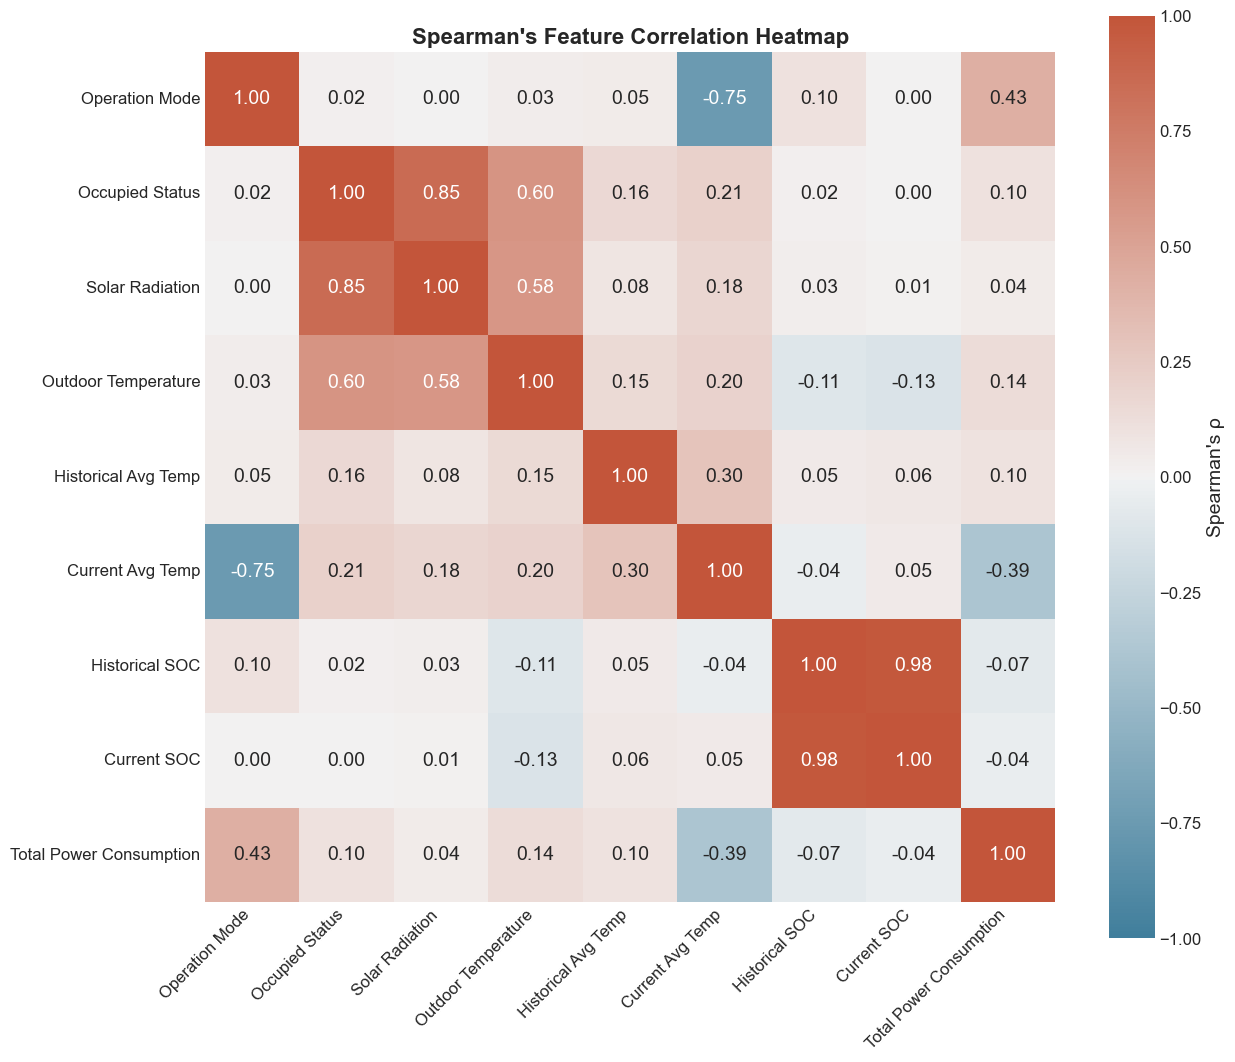

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Select relevant columns
df_SOC = df[['tesBed.uModActual.y',        
             'tesBed.occSch.occupied',     
             'tesBed.weaBus.HGloHor',      
             'tesBed.TOut.y',              
             'tesBed.ave.y_his1',          
             'tesBed.ave.y',               # ← Current Avg Temp
             'tesBed.iceTan.SOC_his1',     
             'tesBed.iceTan.SOC',          
             'Ptot'                        # ← Total Power
            ]]

# Step 2: Rename columns to plain language
df_SOC = df_SOC.rename(columns={
    'tesBed.uModActual.y': 'Operation Mode',
    'tesBed.occSch.occupied': 'Occupied Status',
    'tesBed.weaBus.HGloHor': 'Solar Radiation',
    'tesBed.TOut.y': 'Outdoor Temperature',
    'tesBed.ave.y_his1': 'Historical Avg Temp',
    'tesBed.ave.y': 'Current Avg Temp',
    'tesBed.iceTan.SOC_his1': 'Historical SOC',
    'tesBed.iceTan.SOC': 'Current SOC',
    'Ptot': 'Total Power Consumption'
})

# Step 3: Compute Spearman correlation
corr_spear = df_SOC.corr(method='spearman')

# Step 4: Plot the heatmap
plt.figure(figsize=(13, 11))
cmap_spear = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_spear, square=True, vmin=-1, vmax=1, cmap=cmap_spear,
            annot=True, fmt=".2f", cbar_kws={'label': "Spearman's ρ"})
plt.title("Spearman's Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Step 5: Save the figure
plt.savefig('results_dnn/correlation_spearman_SOC_updated.png', dpi=300)
plt.show()


Temperature Model - Compute the correlation between variables. Create heat maps to visualize the correlation matrixes.

In [15]:
df_Tz = df[['tesBed.uModActual.y', # -1: Charge TES; 0: off; 1: Discharge TES; 2: Discharge chiller
            #'bChi.y', # Chiller on/off
            #'bIce.y', # TES on/off
            #'tesBed.occSch.occupied','tesBed.iceTan.SOC_his1',
            #'tesBed.conVAVCor.TZon_his4','tesBed.conVAVCor.TZon_his3','tesBed.conVAVCor.TZon_his2',
            'tesBed.conVAVCor.TZon_his1', 
            #'tesBed.TOut.y_his4','tesBed.TOut.y_his3','tesBed.TOut.y_his2','tesBed.TOut.y_his1',
            #'tesBed.weaBus.HGloHor_his4','tesBed.weaBus.HGloHor_his3','tesBed.weaBus.HGloHor_his2','tesBed.weaBus.HGloHor_his1',
            'tesBed.conVAVCor.TZon',
            ]] 
df_Tz.describe()

,tesBed.uModActual.y,tesBed.conVAVCor.TZon_his1,tesBed.conVAVCor.TZon
count,740.000000,740.000000,740.000000
mean,0.504054,25.536740,25.537883
std,1.116361,1.381713,1.380618
min,-1.000000,22.888970,22.888970
25%,0.000000,24.250703,24.251975
50%,0.000000,25.176670,25.176670
75%,2.000000,26.717150,26.717150
max,2.000000,28.527400,28.527400


Temperature Model - Distribution of each feature

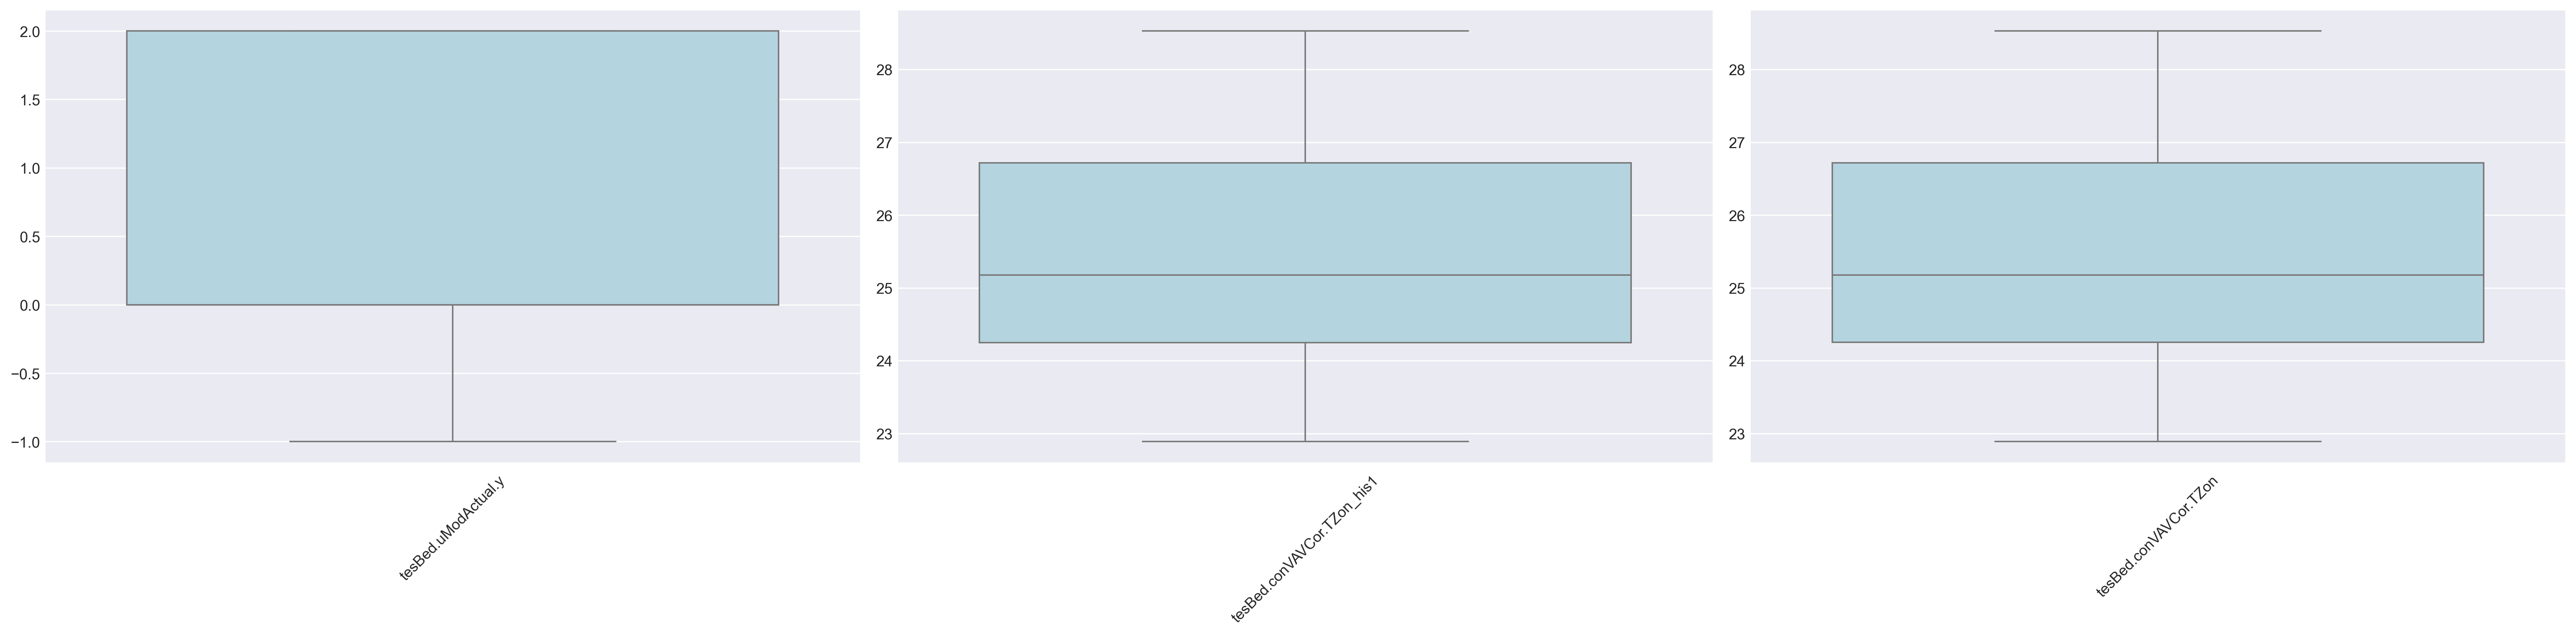

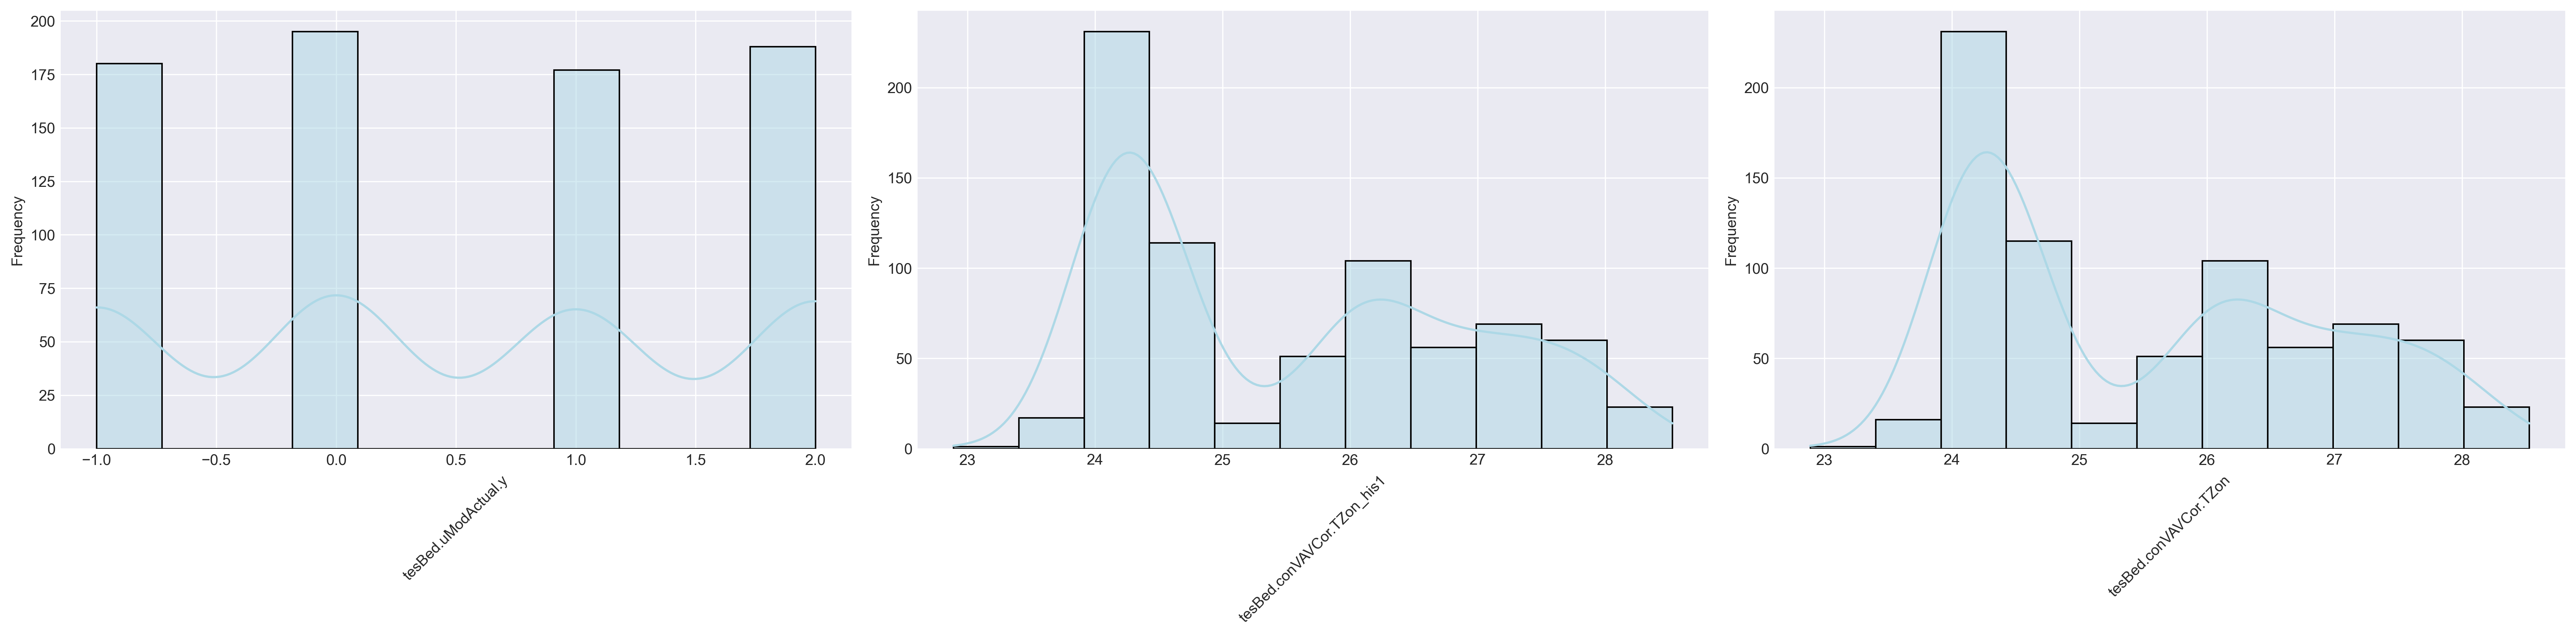

In [16]:
data_df = df_Tz
targets = [t for t in data_df.columns]

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.boxplot(data=data_df, y=value, color="lightblue", ax=axs[count]) #
    axs[count].set_xlabel(value, rotation=45)
    axs[count].set_ylabel('')
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

fig, axs = plt.subplots(1, len(targets), figsize=(24,6), dpi=300)
for count, value in enumerate(targets):
    sns.histplot(data=data_df, x=value, color="lightblue", kde=True, ax=axs[count])
    axs[count].set_xlabel(value, rotation=45) # Rotate x-axis labels
    axs[count].set_ylabel('Frequency')
    #axs[count].tick_params(axis='x', rotation=45)  # Rotate x-axis tick labels by 45 degrees
plt.tight_layout()  # Automatically adjusts subplots to fit into figure area

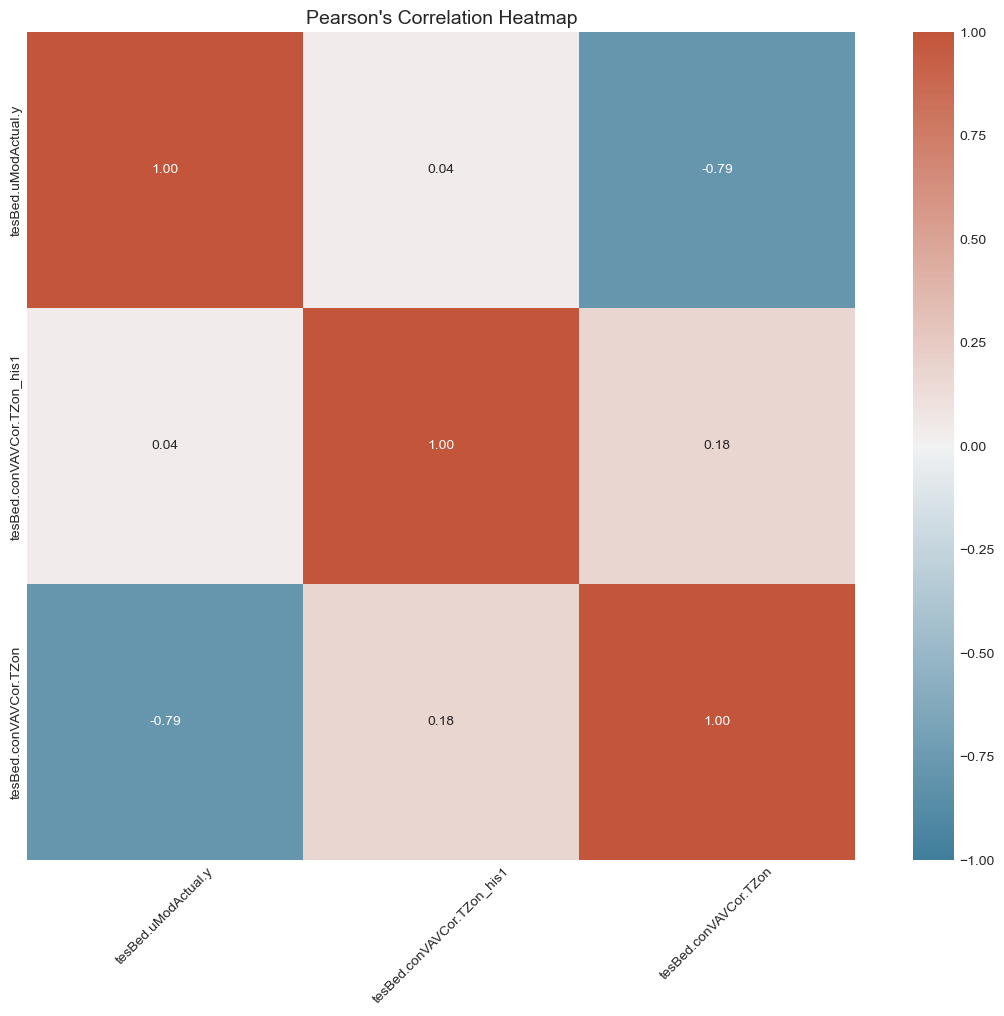

In [17]:
# Increase the figure size
plt.figure(figsize=(12, 10))

corr_Tz = df_Tz.corr(method='pearson')
cmap_Tz = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_Tz, square=True, vmin=-1, vmax=1, cmap=cmap_Tz, annot=True, fmt=".2f")

# Add a title
plt.title("Pearson's Correlation Heatmap", fontsize=14)

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()  # Adjusts the padding so that everything fits in the figure area

# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_pearson_Tz.png', dpi=300)


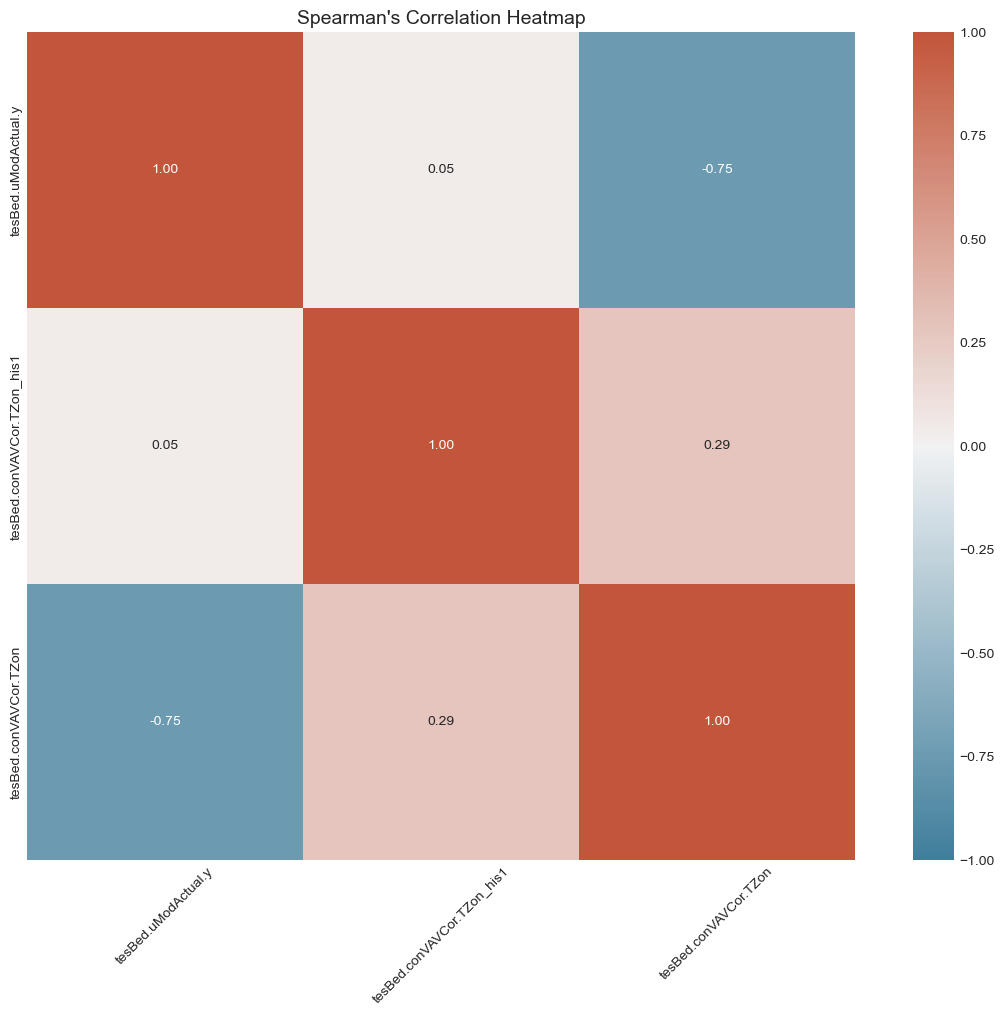

In [18]:
plt.figure(figsize=(12, 10))

corr_spear_Tz = df_Tz.corr(method='spearman')
cmap_spear_Tz = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_spear_Tz, square=True, vmin=-1, vmax=1, cmap=cmap_spear_Tz, annot=True, fmt=".2f")
# Add a title
plt.title("Spearman's Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout() 

# Save the figure with high resolution (e.g., 300 dpi)
plt.savefig('results_dnn/correlation_spearman_Tz.png', dpi=300)

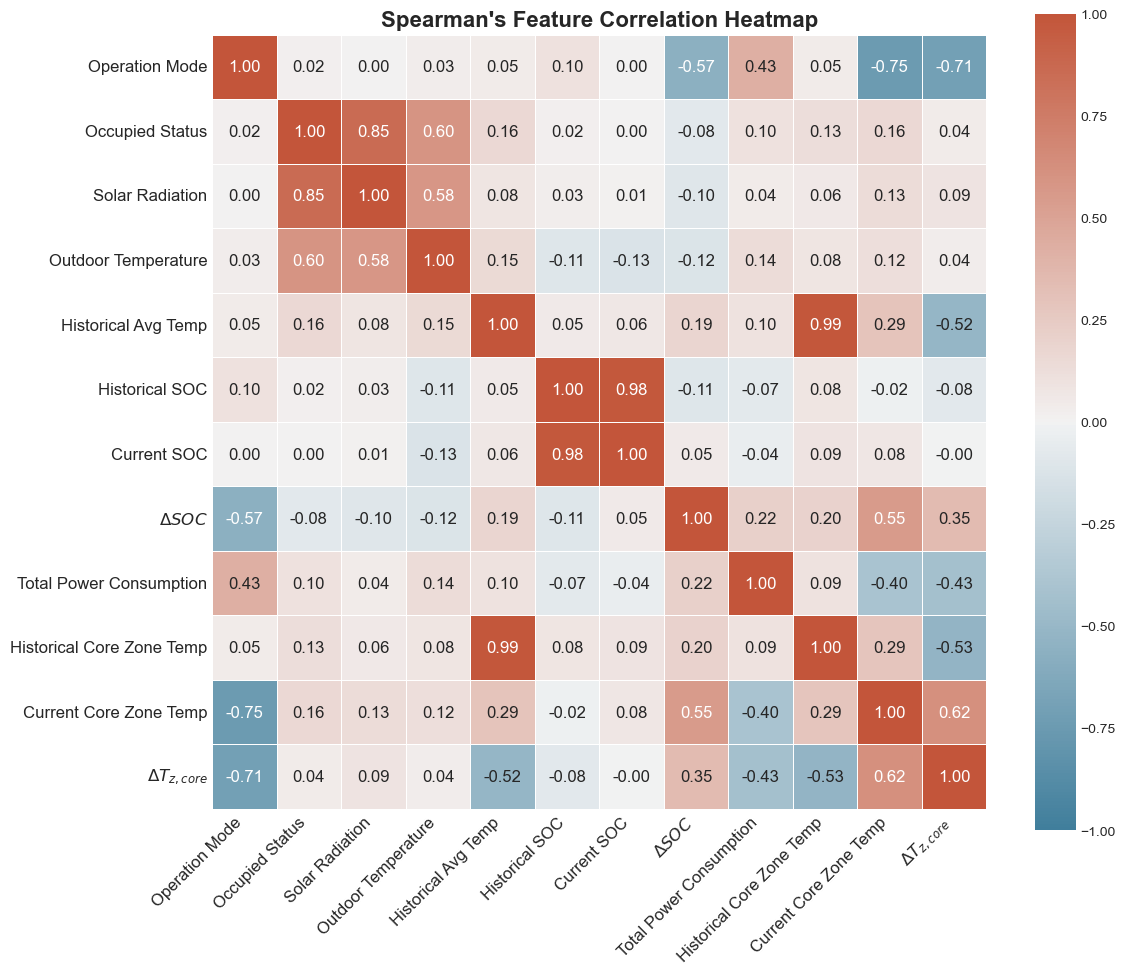

In [ ]:

# Select relevant features
df_Tz_core = df[['tesBed.uModActual.y',     # -1: Charge TES; 0: off; 1: Discharge TES; 2: Discharge chiller
             'tesBed.occSch.occupied',      # Occupied status
             'tesBed.weaBus.HGloHor',       # Global horizontal solar radiation
             'tesBed.TOut.y',               # Outdoor air temperature
             'tesBed.ave.y_his1',           # Historical average zone temperature
             'tesBed.iceTan.SOC_his1',      # Historical SOC
             'tesBed.iceTan.SOC',           # Target SOC
             'delta_SOC',                   # Change in SOC
             'Ptot',                        # Total Power Consumption
             'tesBed.conVAVCor.TZon_his1',  # Historical thermal zone temperature
             'tesBed.conVAVCor.TZon',       # Current thermal zone temperature
             'delta_Tz_core',               # Change in thermal zone temperature
            ]]

# Rename columns to plain language
df_Tz_core = df_Tz_core.rename(columns={
    'tesBed.uModActual.y': 'Operation Mode',
    'tesBed.occSch.occupied': 'Occupied Status',
    'tesBed.weaBus.HGloHor': 'Solar Radiation',
    'tesBed.TOut.y': 'Outdoor Temperature',
    'tesBed.ave.y_his1': 'Historical Avg Temp',
    'tesBed.iceTan.SOC_his1': 'Historical SOC',
    'tesBed.iceTan.SOC': 'Current SOC',
    'delta_SOC': '$\Delta SOC$',
    'Ptot': 'Total Power Consumption',
    'tesBed.conVAVCor.TZon_his1': 'Historical Core Zone Temp',
    'tesBed.conVAVCor.TZon': 'Current Core Zone Temp',
    'delta_Tz_core': '$\Delta T_{z,core}$'
})

# Calculate Spearman correlation
corr_spear = df_Tz_core.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12, 10))
cmap_spear = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_spear, square=True, vmin=-1, vmax=1, cmap=cmap_spear,
            annot=True, fmt=".2f", annot_kws={"size": 12}, linewidths=0.5)

# Customize appearance
plt.title("Spearman's Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig('results_dnn/correlation_spearman_moreFeatures_Tz_core.png', dpi=300)
plt.show()
